In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datas pt-BR
import locale
locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8')


'pt_BR.UTF-8'

## Importação e Contexto dos Dados

Os dados do presente notebook foram extraídos do site da Pós-Graduação em Física da UFMG que cobre o Corpo Discente do Programa. 

__Fonte:__ [Física UFMG = Corpo Discente do 2º semestre de 2025]("https://www.fisica.ufmg.br/posgraduacao/corpo-discente/")

In [2]:
# Source of data: 
source_data: str = "https://www.fisica.ufmg.br/posgraduacao/corpo-discente/"

# Loading data
mest, doc = pd.read_html(source_data, header=1)
mest["Modalidade"] = "Mestrado"
doc["Modalidade"] = "Doutorado"

# Remover a última linha do mestrado 
mest = mest.head(-1)
pos_grad = pd.concat([mest, doc], axis=0)
pos_grad = pos_grad.drop(columns="Matrícula")
pos_grad.sample(5)

,Aluno/a,Entrada,Área de Concentração,Orientador/a,Bolsista,Agência,Início bolsa,Término bolsa,Prazo término curso,Modalidade
71,Renato Veloso Amaral Boaventura,mar/23,Física,Rodrigo Gribel,Sim,CNPQ,mar/23,fev/27,fev/28,Doutorado
31,Júlio César Lopes da Fonseca,mar/25,Física Aplicada e Interdisciplinar,Michele Hidemi Ueno Guimarães,Sim,CNPq/PRPG,jun/25,jul/27,ago/27,Mestrado
44,Miriam De Fátima Soares,out/24,Física Aplicada e Interdisciplinar,Rogério Paniago,Não,NaN,NaN,NaN,mar/27,Mestrado
7,Bernardo Maia Mendonça Silveira,out/24,Física,Emmanuel Araújo Pereira,Não,NaN,NaN,NaN,mar/27,Mestrado
30,Hiago Maurilio Lopes Carvalho,mai/21,Física,Ricardo Wagner Nunes,Não,NaN,NaN,NaN,nov/26,Doutorado


## Tratamento dos Dados

__Renomeando Colunas__


In [3]:
pos_grad.head(0)

,Aluno/a,Entrada,Área de Concentração,Orientador/a,Bolsista,Agência,Início bolsa,Término bolsa,Prazo término curso,Modalidade


In [4]:
# Renomeando colunas 
pos_grad.columns = pos_grad.columns.str.replace(" ", "_").str.lower()

# Removendo caracteres ( ´ , ç , ^)
cols_rename: dict[str, str] = {
    "matrícula": "matricula",
    "área_de_concentração": "area_de_concentracao",
    "agência": "agencia",
    "início_bolsa": "inicio_bolsa",
    "término_bolsa": "termino_bolsa",
    "prazo_término_curso": "prazo_termino_curso",
}
pos_grad = pos_grad.rename(columns=cols_rename)
pos_grad.head(0)

,aluno/a,entrada,area_de_concentracao,orientador/a,bolsista,agencia,inicio_bolsa,termino_bolsa,prazo_termino_curso,modalidade


__Tipos de dados__

In [5]:
pos_grad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 0 to 82
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   aluno/a               152 non-null    object
 1   entrada               152 non-null    object
 2   area_de_concentracao  151 non-null    object
 3   orientador/a          152 non-null    object
 4   bolsista              152 non-null    object
 5   agencia               108 non-null    object
 6   inicio_bolsa          107 non-null    object
 7   termino_bolsa         107 non-null    object
 8   prazo_termino_curso   152 non-null    object
 9   modalidade            152 non-null    object
dtypes: object(10)
memory usage: 13.1+ KB


In [6]:
# Mudaremos colunas do tipo genérico object para tipos específicos.
# Format: mês/ano (jan/XX)
cols_datetime = ["entrada", "inicio_bolsa", "termino_bolsa", "prazo_termino_curso"] 
for col in cols_datetime:
    pos_grad[col] = pd.to_datetime(pos_grad[col], format="%b/%y")

In [7]:
# Convertendo bolsista para booleano
print("Valores únicos de bolsista (antes)", pos_grad["bolsista"].unique())
map_bolsista: dict[str, bool] = {"sim": True, "não": False}
pos_grad["bolsista"] = pos_grad["bolsista"].str.lower().map(map_bolsista)
print("Valores únicos de bolsista (depois)", pos_grad["bolsista"].unique())


Valores únicos de bolsista (antes) ['Não' 'Sim' 'SIm']
Valores únicos de bolsista (depois) [False  True]


__Formatação de Strings__

In [8]:
print(f"Agências de Fomento: {pos_grad["agencia"].unique()}")
# Correção do typo CNPq/PRPG
pos_grad["agencia"] = pos_grad["agencia"].str.upper()
print(f"Agências de Fomento: {pos_grad["agencia"].unique()}")


Agências de Fomento: [nan 'CAPES' 'CNPq/PRPG' 'FAPEMIG' 'CNPQ' 'CAPES/PRPG' 'CNPQ/PRPG']
Agências de Fomento: [nan 'CAPES' 'CNPQ/PRPG' 'FAPEMIG' 'CNPQ' 'CAPES/PRPG']


In [9]:
# Formatando nome de pessoas com "Nome Sobrenome Sobrenome2" 
for col in ["aluno/a", "orientador/a"]:
    pos_grad[col] = pos_grad[col].str.title().str.strip()


---

## Configurações Globais dos Plots

In [10]:
from pyfonts import load_google_font

font = load_google_font("Montserrat")
boldfont = load_google_font("Montserrat", weight="bold")
digit_font = load_google_font("Lato", weight="bold")

config = {
    'figure.facecolor': 'whitesmoke',
    'axes.facecolor': 'whitesmoke',
    'axes.titleweight': 'bold' # Aproveitando para negritar títulos
}

plt.rcParams.update(config)

---

## Análise Exploratória dos Dados

### Visão Geral do Programa 

In [11]:
ct_modalidade_area = pd.crosstab(
    index=pos_grad["modalidade"],
    columns=pos_grad["area_de_concentracao"]
)
ct_modalidade_area
# Ordenando pela maior quantidade
ct_indexes_sorted = ct_modalidade_area.sum().sort_values(ascending=False).index
ct_modalidade_area = ct_modalidade_area[ct_indexes_sorted]
ct_modalidade_area

area_de_concentracao,Física,Física Aplicada e Interdisciplinar,Astrofísica
modalidade,,,
Doutorado,77,0,6
Mestrado,40,19,9


In [12]:
contagem_alunos: pd.Series = pos_grad["modalidade"].value_counts()
contagem_alunos

modalidade
Doutorado    83
Mestrado     69
Name: count, dtype: int64

In [13]:
areas_conce: pd.Series = pos_grad["area_de_concentracao"].value_counts()
areas_conce

area_de_concentracao
Física                                117
Física Aplicada e Interdisciplinar     19
Astrofísica                            15
Name: count, dtype: int64

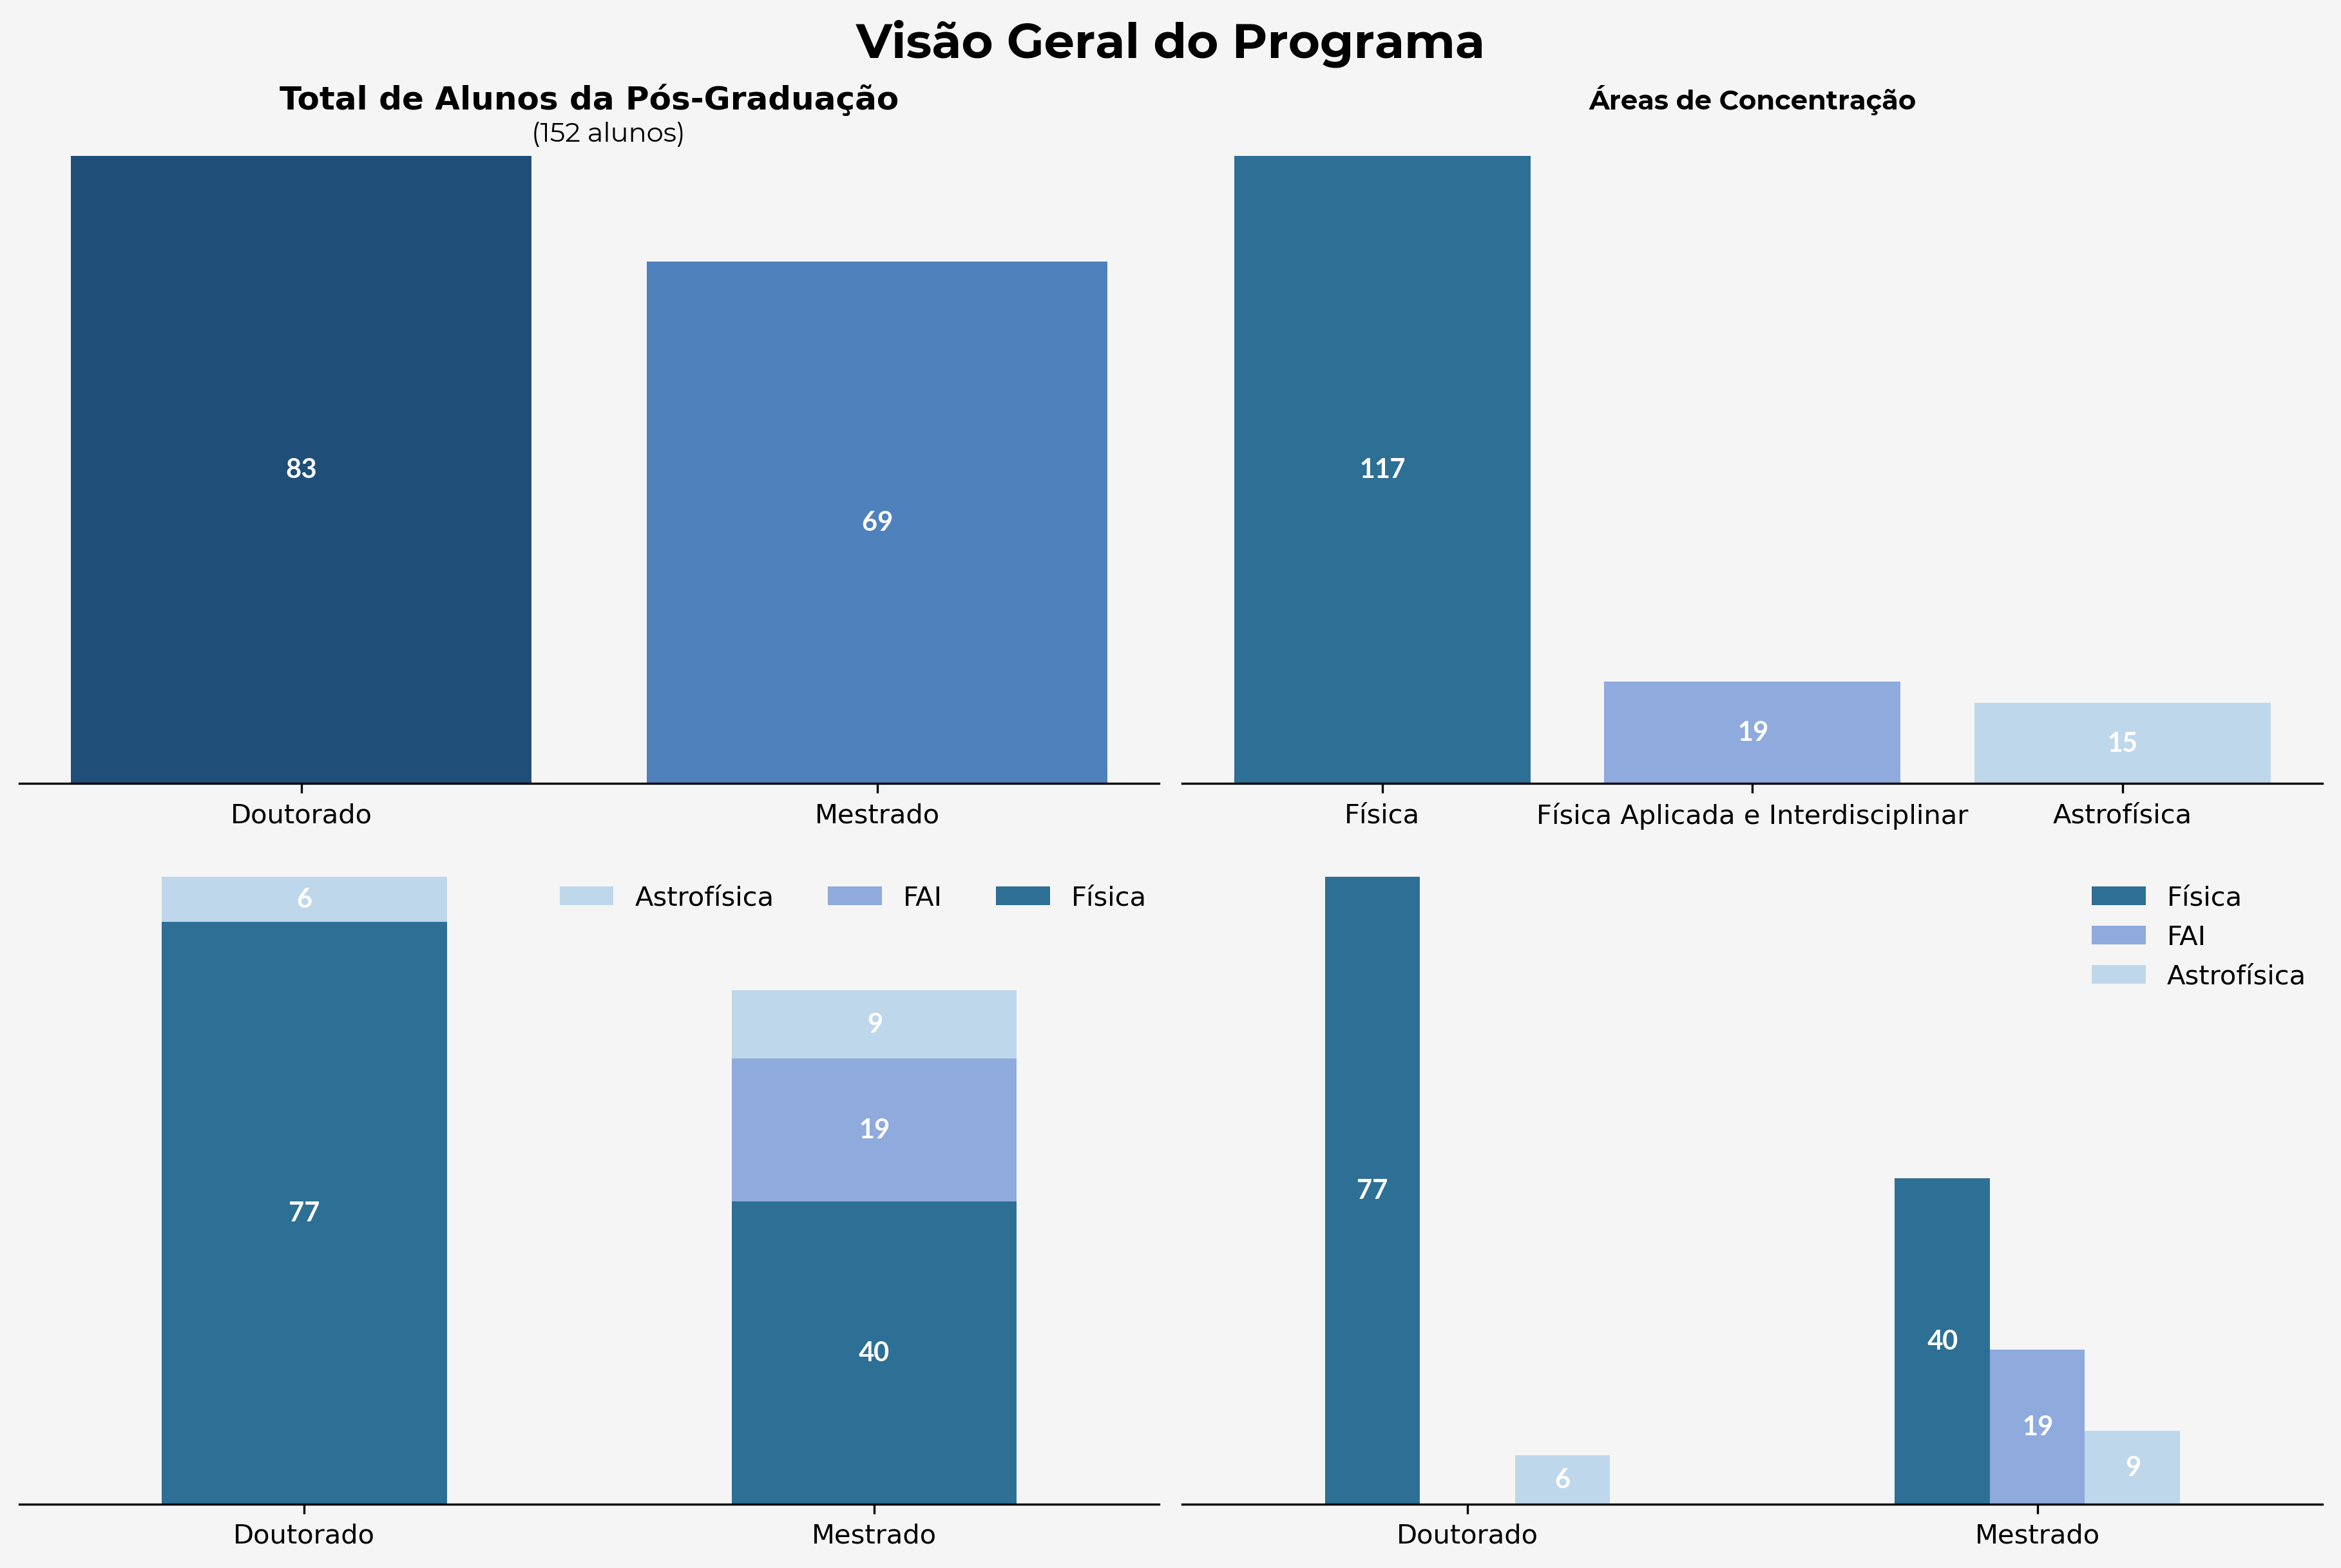

In [14]:
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(12, 8), dpi=300, layout="constrained")
ax1, ax2, ax3, ax4 = axs.flatten()
fig.suptitle("Visão Geral do Programa", font=boldfont, size=18)
# --- AX1 ---
# Contagem Alunos
ax1.set_title("Total de Alunos da Pós-Graduação")
ax1.text(x=0.4, y=85, s=f"({83 + 69} alunos)", font=font)   # Subtitulo
sns.despine(left=True, ax=ax1)
ax1.set_yticks([])
cores = ["#1F4E79", "#4F81BD"]
bars = ax1.bar(x=contagem_alunos.index, height=contagem_alunos.values, color=cores)
ax1.bar_label(bars, label_type="center", color="white", font=digit_font)

# --- AX2 ---
# Áreas de Concentração
ax2.set_title("Áreas de Concentração", font=boldfont)
cores = ["#2E6F95", "#8FAADC", "#BFD7EA"]
ax2.bar(x=areas_conce.index, height=areas_conce.values, color=cores)
ax2.bar_label(
    container=ax2.containers[0], label_type="center", font=digit_font, color="white"
)
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.set_yticks([])
sns.despine(left=True, ax=ax2)

# --- AX3 ---
# Barras Empilhadas
ct_modalidade_area.plot(kind="bar", stacked=True, ax=ax3, legend=False, color=cores)
sns.despine(left=True, ax=ax3)
ax3.set_yticks([])
ax3.set_xlabel("")

# --- AX4 ---
# Barras Agrupadas
sns.despine(left=True, ax=ax4)
ct_modalidade_area.plot(kind="bar", stacked=False, ax=ax4, legend=False, color=cores)
ax4.set_xlabel("")
ax4.set_yticks([])

for ax in (ax3, ax4):
    ax.tick_params(axis="x", rotation=0)
    for i, bar_container in enumerate(ax3.containers):
        ax.bar_label(
            ax.containers[i],
            label_type="center",
            font=digit_font,
            fmt=lambda x: f"{int(x)}" if x > 0 else "",
            color="white",
        )

handles, labels = ax3.get_legend_handles_labels()
labels[1] = "FAI"

fig.legend(
    handles=handles,
    labels=labels,
    bbox_to_anchor=(0.50, 0.45),
    ncols=3,
    frameon=False,
    reverse=True,
)
fig.legend(handles=handles, labels=labels, bbox_to_anchor=(1.0, 0.45), frameon=False)

fig.savefig("VisaoGeral_DF.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Estrutura de Fomento

In [15]:
ct_modalidade_bolsista = pd.crosstab(
    index=pos_grad["modalidade"],
    columns=pos_grad["bolsista"],
)
display(ct_modalidade_bolsista)
print(ct_modalidade_bolsista.columns)

bolsista,False,True
modalidade,,
Doutorado,20,63
Mestrado,24,45


Index([False, True], dtype='bool', name='bolsista')


In [16]:
ct_modalidade_bolsista= ct_modalidade_bolsista.rename(columns={False: "Não", True: "Sim"})
display(ct_modalidade_bolsista)
print(ct_modalidade_bolsista.columns)

# Mudei os nomes para "Sim" e "Não" para conseguir ordenar as colunas.
# Com dtype bool o ordenamento das barras confunde com as máscaras do Pandas

ct_modalidade_bolsista.sort_index(ascending=False, inplace=True)

# Além disso deixei primeiro Doutorado e depois Mestrado para acompanhar as outras barras

bolsista,Não,Sim
modalidade,,
Doutorado,20,63
Mestrado,24,45


Index(['Não', 'Sim'], dtype='object', name='bolsista')


In [17]:
# Percentual (proportion)
(pos_grad["bolsista"].value_counts(normalize=True) * 100).round(2)

bolsista
True     71.05
False    28.95
Name: proportion, dtype: float64

In [18]:
pos_grad["bolsista"].value_counts()

bolsista
True     108
False     44
Name: count, dtype: int64

In [19]:
ct_modalidade_bolsista

bolsista,Não,Sim
modalidade,,
Mestrado,24,45
Doutorado,20,63


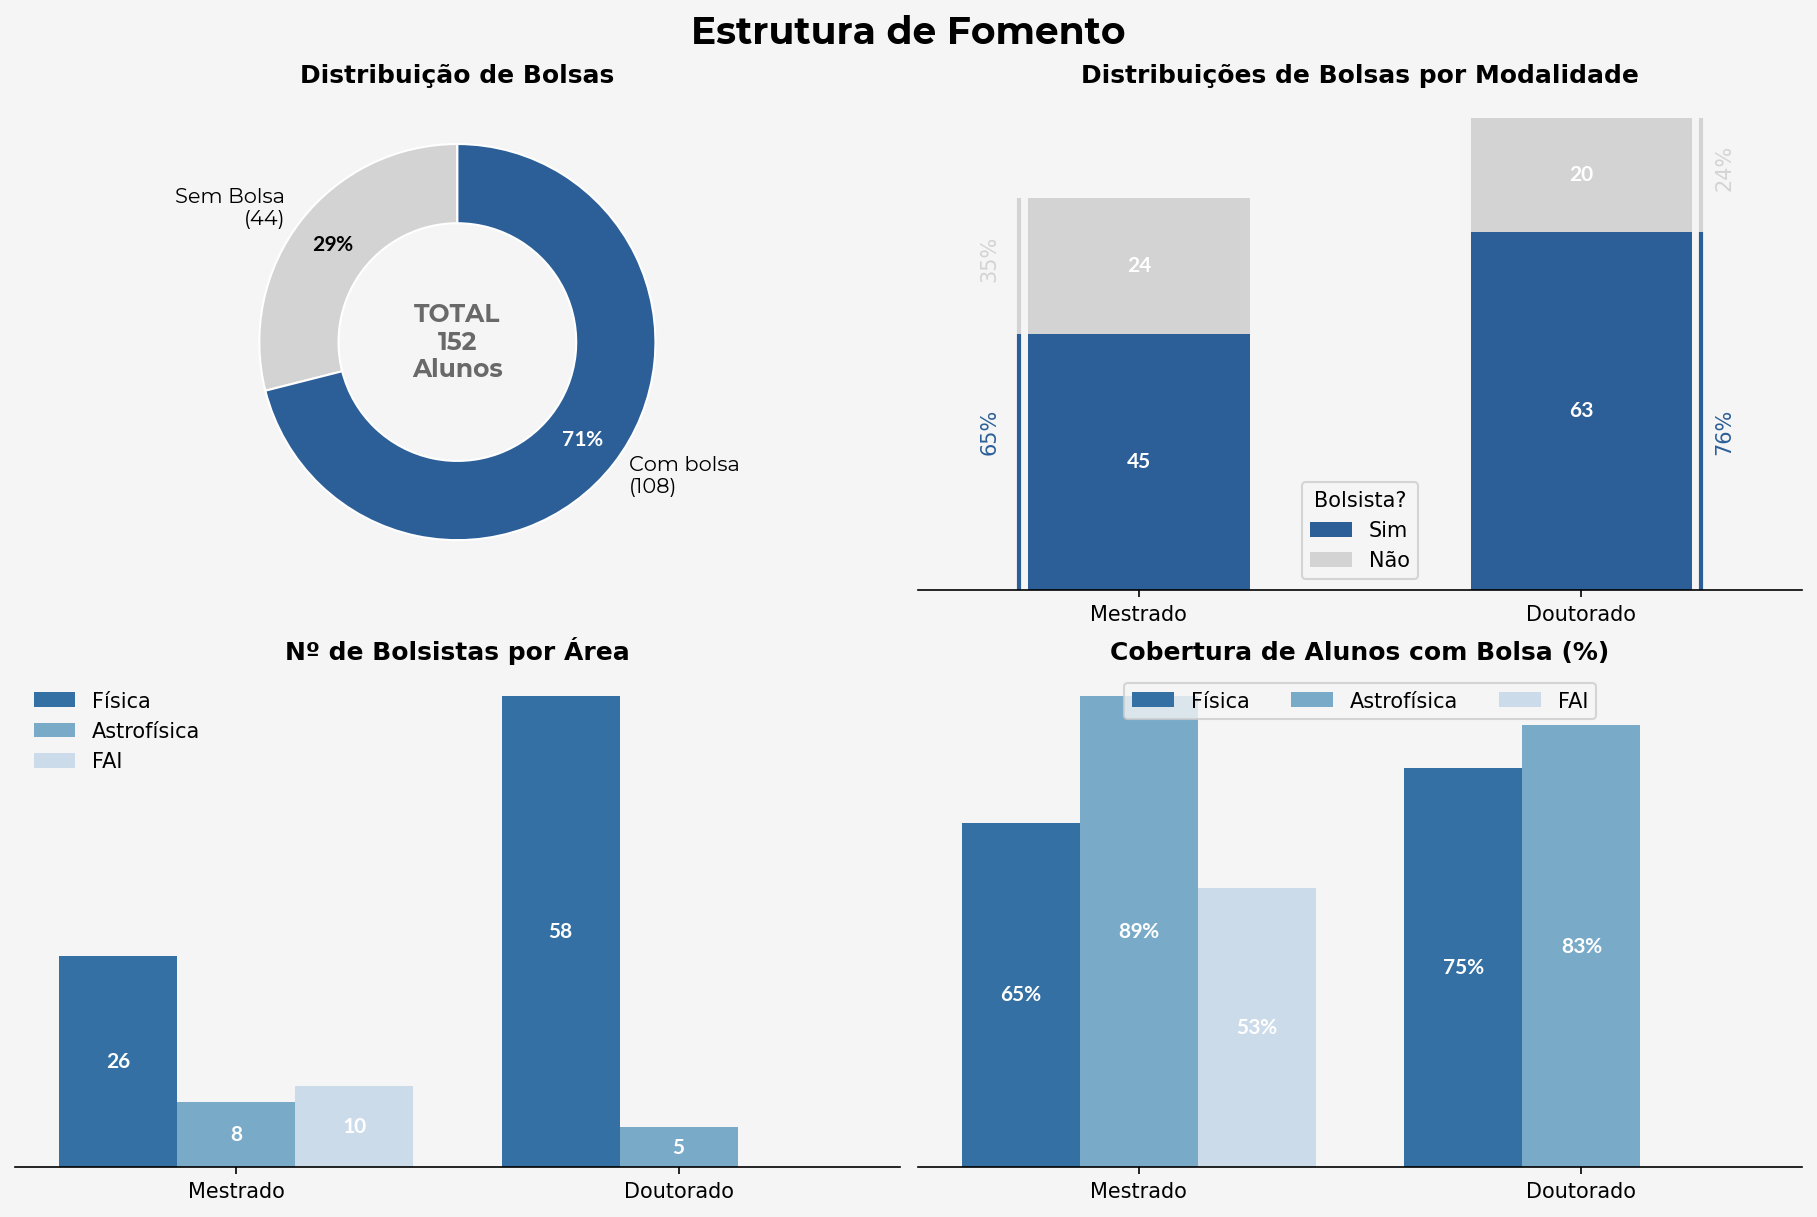

In [20]:
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(12, 8), dpi=150, layout="constrained"
)
fig.suptitle("Estrutura de Fomento", font=boldfont, size=18)
ax1, ax2, ax3, ax4 = axs.flatten()

# --- AX1 ---
# Pie Chart
ax1.set_title("Distribuição de Bolsas")
bolsas_alunos = ct_modalidade_bolsista.sum()
cores = ["#D3D3D3", "#2C5F98"]
wedges, texts, autotexts = ax1.pie(
    bolsas_alunos,
    labels=["Sem Bolsa\n(44)", "Com bolsa\n(108)"],
    colors=cores,
    autopct="%1.f%%",
    startangle=90,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor="w"),  # width=0.4 cria o buraco (Rosca)
)
plt.setp(autotexts, font=digit_font)
autotexts[1].set_color("white")
plt.setp(texts, font=font)

ax1.text(
    0,
    0,
    f"TOTAL\n{bolsas_alunos.sum()}\nAlunos",
    ha="center",
    va="center",
    font=boldfont,
    fontsize=12,
    color="dimgrey",
)

# --- AX2 ---
# Bolsas Mestrado vs Doutorado
ax2.set_title("Distribuições de Bolsas por Modalidade")
ct_modalidade_bolsista[["Sim", "Não"]].plot(
    kind="bar", stacked=True, color=cores[::-1], ax=ax2
)
ax2.tick_params(axis="x", rotation=0)
ax2.set_xlabel("")
ax2.legend(title="Bolsista?")
sns.despine(ax=ax2, left=True)
ax2.set_yticks([])
for i, bar_container in enumerate(ax2.containers):
    ax2.bar_label(
        ax2.containers[i], label_type="center", font=digit_font, color="white"
    )


## --- Barras Mestrado (Esquerda)
mestrado_com_bolsa: int = ct_modalidade_bolsista.loc["Mestrado", "Sim"]  # 45
mestrado_sem_bolsa: int = ct_modalidade_bolsista.loc["Mestrado", "Não"]  # 24
total_mest = mestrado_com_bolsa + mestrado_sem_bolsa

ax2.vlines(x=-0.27, ymin=0, ymax=mestrado_com_bolsa, color=cores[1], lw=2)
ax2.text(
    x=-0.36,
    y=24.5,
    s=f"{mestrado_com_bolsa / (total_mest):.0%}",
    rotation=90,
    color=cores[1],
)
ax2.vlines(x=-0.27, ymin=mestrado_com_bolsa, ymax=total_mest, color=cores[0], lw=2)
ax2.text(
    x=-0.36,
    y=55,
    s=f"{mestrado_sem_bolsa / (total_mest):.0%}",
    rotation=90,
    color=cores[0],
)

## ---  Barras Doutorado (Direita)
doutorado_com_bolsa: int = ct_modalidade_bolsista.loc["Doutorado", "Sim"]  # 63
doutorado_sem_bolsa: int = ct_modalidade_bolsista.loc["Doutorado", "Não"]  # 20
total_doc = doutorado_com_bolsa + doutorado_sem_bolsa
ax2.vlines(x=1.27, ymin=0, ymax=doutorado_com_bolsa, color=cores[1], lw=2)
ax2.text(
    x=1.3,
    y=24.5,
    s=f"{doutorado_com_bolsa / (total_doc):.0%}",
    rotation=90,
    color=cores[1],
)  # Sim
ax2.vlines(x=1.27, ymin=doutorado_com_bolsa, ymax=total_doc, color=cores[0], lw=2)
ax2.text(
    x=1.3,
    y=71,
    s=f"{doutorado_sem_bolsa / (total_doc):.0%}",
    rotation=90,
    color=cores[0],
)


# --- AX3 ---
# Distribuição de Bolsas por área
bolsistas = pos_grad.query("bolsista == True")
ax3.set_title("Nº de Bolsistas por Área")
sns.despine(left=True, ax=ax3)
sns.countplot(
    data=bolsistas,
    x="modalidade",
    hue="area_de_concentracao",
    palette="Blues_r",
    ax=ax3,
)
ax3.set_ylabel("")
ax3.set_xlabel("")
ax3.set_yticks([])
for i, bar_container in enumerate(ax3.containers):
    ax3.bar_label(
        ax3.containers[i], label_type="center", font=digit_font, color="white"
    )
handles, labels = ax3.get_legend_handles_labels()
labels[2] = "FAI"
ax3.legend(handles=handles, labels=labels, title="", frameon=False, loc="upper left")

# --- AX4 ---
# Cobertura de Bolsas por Área (%)
ax4.set_title("Cobertura de Alunos com Bolsa (%)")
sns.barplot(
    data=pos_grad,
    x="modalidade",
    y="bolsista",
    hue="area_de_concentracao",
    palette="Blues_r",
    errorbar=None,
    ax=ax4,
)
ax4.set_xlabel("")
ax4.set_ylabel("")
for i, bar_container in enumerate(ax4.containers):
    ax4.bar_label(
        ax4.containers[i],
        label_type="center",
        font=digit_font,
        color="white",
        fmt=lambda x: f"{x:.0%}",
    )
ax4.set_yticks([])
handles, labels = ax4.get_legend_handles_labels()
labels[2] = "FAI"
ax4.legend(handles=handles, labels=labels, title="", ncols=3, loc="upper center")
sns.despine(left=True, ax=ax4)
# ---


fig.savefig("EstruturaDeFomento.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Datas e Durações